# 02 · Adverse selection — measured against real quotes

This notebook measures the adverse selection a passive market maker faces on BTCUSDT, and
does it **twice**: once with a 1-second trade-price *proxy* for the mid, and once with the
real bid/ask from the futures **`bookTicker`** feed. The gap between the two is the finding —
a direct measurement of how far a plausible-looking proxy pushes each estimate.

**The arc this completes.** Earlier rounds of this project measured the mid three ways:
1. a *centred* trade proxy that peeked into the future — a lookahead bug that produced a
   spurious "naive loses ~2.5× the spread" headline;
2. a *causal* trade proxy that fixed the lookahead but still could not resolve BTC's true
   spread (its "penetration depths" were ~1s of volatility, not book depth), so it honestly
   **declined to quote a spread-vs-markout ratio at all**;
3. **real quotes** (this notebook), where the touch half-spread is directly observable and
   the ratio becomes defensible.

Everything is on the BTCUSDT **futures** market for one day (2024-01-15), because that is
where `bookTicker` exists — and the trade tape must be from the same market as the quotes
(spot trades sit at a basis to the futures book).

In [1]:
from mmlab import self_test
self_test()

mm-lab self-test
  [PASS] 1. gamma->0: edge term -> 2/kappa and reservation -> mid  — edge=1.33333 vs 2/kappa=1.33333
  [PASS] 2. q=0 => reservation price == mid
  [PASS] 3. total PnL == spread + inventory PnL  — max residual=5.68e-13
  [PASS] 4. A=0 => zero fills, inventory and PnL


  [PASS] 5. measured fill rate == A*exp(-kappa*delta)  — measured=0.2211 vs expected=0.2231
  [PASS] 6. calibration recovers known A and kappa  — A=2.034 (true 2.0), kappa=1.520 (true 1.5)
  [PASS] 7. AS terminal-inventory std < naive  — AS std=0.71 < naive std=13.79
all checks passed.


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmlab import quotes, data, calibrate, markout, simulate, strategies, metrics
from mmlab.config import get_rng
from mmlab.plotting import apply_style, CLR, style_table
apply_style()

DATE = '2024-01-15'
HORIZONS = [1, 5, 10, 30, 60, 300]

## The data — real quotes, with two landmines handled

`bookTicker` gives the best bid/ask on every book update (~20M/day). Two things must be
right before any measurement:

- **Sequence.** Binance's own tracker (binance-public-data#305) reports some Jan-2024
  BTC/ETH `bookTicker` files are out of time order. `load_bookticker` sorts by the
  matching-engine `update_id`, asserts `transaction_time` is non-decreasing after, and
  reports how many rows were out of order (below).
- **Same market.** The quotes are futures, so the trades must be too — `quotes.load_futures_aggtrades`,
  not the spot tape in `data.py` (spot trades sit at a basis to the futures book and would
  measure the basis, not penetration). The download is checksum-verified against the archive's
  `.CHECKSUM`.

In [3]:
trades = quotes.load_futures_aggtrades('BTCUSDT', [DATE])
q = quotes.load_bookticker('BTCUSDT', DATE)     # prints the out-of-sequence count
tq = q['time'].to_numpy()
true_mid = quotes.quote_mid(q)
S0 = float(np.median(true_mid))
dur = float(trades['time'].max() - trades['time'].min())
price = trades['price'].to_numpy(); ibm = trades['is_buyer_maker'].to_numpy(); ttime = trades['time'].to_numpy()
print(f'{len(trades):,} futures trades; {len(q):,} quote updates; mid ~ {S0:,.0f} USDT')

  [ok]   futures BTCUSDT 2024-01-15: 1,036,190 trades


1,036,190 futures trades; 19,881,490 quote updates; mid ~ 42,646 USDT


## Measurement 1 — the touch half-spread (the number the proxy could not give)

`(ask − bid)/2` is directly observable now, per quote update. It is the **ceiling on what a
maker resting at the touch captures per fill** — the quantity the whole "is market making
profitable?" question turns on.

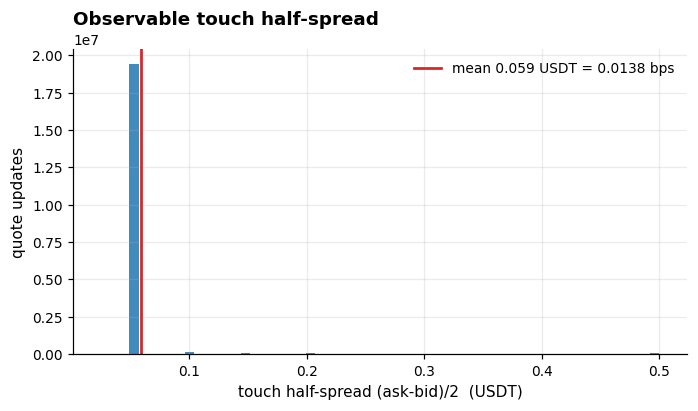

touch half-spread: mean 0.0587 USDT (0.0138 bps), median 0.0500 USDT (0.0117 bps)
for scale: one tick = 0.10 USDT = 0.0234 bps


In [4]:
ths = quotes.touch_half_spread(q)
ths_bps = 1e4 * ths.mean() / S0
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.hist(np.clip(ths, 0, 0.5), bins=60, color=CLR['AS'], alpha=0.85)
ax.axvline(ths.mean(), color='#d62728', lw=1.8, label=f'mean {ths.mean():.3f} USDT = {ths_bps:.4f} bps')
ax.set_xlabel('touch half-spread (ask-bid)/2  (USDT)'); ax.set_ylabel('quote updates')
ax.set_title('Observable touch half-spread'); ax.legend(); plt.show()
print(f'touch half-spread: mean {ths.mean():.4f} USDT ({ths_bps:.4f} bps), '
      f'median {np.median(ths):.4f} USDT ({1e4*np.median(ths)/S0:.4f} bps)')
print(f'for scale: one tick = 0.10 USDT = {1e4*0.10/S0:.4f} bps')

## Measurement 2 — recalibrate `sigma` and `kappa`: proxy vs true mid

Same estimators, two mids. For `kappa`, a trade's penetration depth is `|price − mid|` using
the causal mid **strictly before** the trade (`quotes.quote_at` for the real book,
`markout._mid_at` on the 1s proxy grid).

In [5]:
# proxy mid (trade-price, 1s causal) on the SAME futures trades
tpm, pm = data.mid_grid(trades, step=1.0, smooth=3)

# sigma: proxy vs true (both on a 1s grid)
sig_proxy = calibrate.realized_sigma(pm, 1.0)
sec = (tq - tq[0]).astype(np.int64)
gmid = pd.Series(true_mid).groupby(sec).last().to_numpy()
sig_true = calibrate.realized_sigma(gmid, 1.0)
ann = lambda s: 100 * s * np.sqrt(365*24*3600) / S0

# kappa: proxy vs true
def fit_both(mid_at_trade, tag):
    ok = np.isfinite(mid_at_trade)
    bd, ad = calibrate.trade_depths(price[ok], mid_at_trade[ok], ibm[ok])
    out = {}
    for name, d in [('bid', bd), ('ask', ad)]:
        A, k, x, lam = calibrate.fit_intensity(d, dur, calibrate.default_delta_grid(d))
        out[name] = (A, k, d.mean())
    return out

proxy_fit = fit_both(markout._mid_at(tpm, pm, ttime), 'proxy')
bd, ak = quotes.quote_at(q, ttime)
true_fit = fit_both(0.5*(bd+ak), 'true')

print(f'sigma  proxy {sig_proxy:.3f} USDT/sqrt-s ({ann(sig_proxy):.0f}%)  |  true {sig_true:.3f} ({ann(sig_true):.0f}%)')
for side in ('bid', 'ask'):
    print(f'kappa {side}  proxy {proxy_fit[side][1]:.3f}/USDT (depth {proxy_fit[side][2]:.2f})  |  '
          f'true {true_fit[side][1]:.3f} (depth {true_fit[side][2]:.2f})')

sigma  proxy 2.338 USDT/sqrt-s (31%)  |  true 3.184 (42%)
kappa bid  proxy 0.165/USDT (depth 6.35)  |  true 0.502 (depth 1.69)
kappa ask  proxy 0.152/USDT (depth 6.32)  |  true 0.465 (depth 1.70)


Both move exactly as a lagged, over-smoothed proxy would predict:

- **`sigma` is higher with the true mid** (≈42% vs ≈31% annualised) — the 1s median smoothing
  that biased it low is gone.
- **`kappa` is ~3× larger with the true mid** — the proxy's penetration depths were dominated
  by ~1s of volatility (mean depth ~6 USDT), so its fill intensity looked far too flat; against
  the real mid the depths are on the scale of actual book penetration (~1–2 USDT). *(The spec
  writing this expected an order-of-magnitude move; it is ~3× here — flagged, not forced.)*

## Measurement 3 — markouts: proxy vs true mid

Same signed markout, both mids. The **1-second** point is the one to watch.

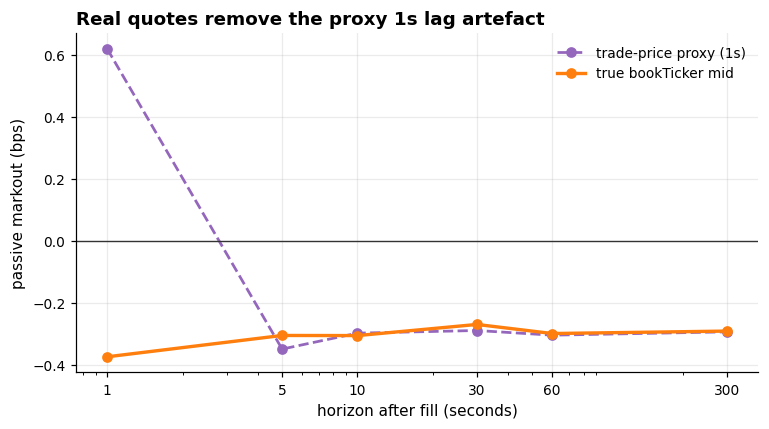

  markout @   1s   proxy +0.619   true -0.373 bps
  markout @   5s   proxy -0.348   true -0.304 bps
  markout @  10s   proxy -0.297   true -0.305 bps
  markout @  30s   proxy -0.288   true -0.269 bps
  markout @  60s   proxy -0.303   true -0.298 bps
  markout @ 300s   proxy -0.293   true -0.290 bps


In [6]:
m_proxy, _ = markout.markout_curve(ttime, price, ibm, tpm, pm, HORIZONS)
m_true, _ = markout.markout_curve(ttime, price, ibm, tq, true_mid, HORIZONS)

fig, ax = plt.subplots(figsize=(8, 4.0))
ax.plot(HORIZONS, [m_proxy[h] for h in HORIZONS], 'o--', color=CLR['markout'], lw=1.8, label='trade-price proxy (1s)')
ax.plot(HORIZONS, [m_true[h] for h in HORIZONS], 'o-', color=CLR['fit'], lw=2.2, label='true bookTicker mid')
ax.axhline(0, color='#333', lw=0.9)
ax.set_xscale('log'); ax.set_xticks(HORIZONS); ax.set_xticklabels([str(h) for h in HORIZONS])
ax.set_xlabel('horizon after fill (seconds)'); ax.set_ylabel('passive markout (bps)')
ax.set_title('Real quotes remove the proxy 1s lag artefact'); ax.legend(); plt.show()
for h in HORIZONS:
    print(f'  markout @{h:>4}s   proxy {m_proxy[h]:+.3f}   true {m_true[h]:+.3f} bps')

The proxy's `+0.62 bps` at 1s was a **pure lag artefact** — it vanishes against the real
mid, which is negative (`−0.37 bps`) from the very first second. At 5s and beyond the two agree
(~`−0.3 bps`): adverse selection is real, and there the proxy was roughly right. So the proxy's
one genuinely misleading output was the short-horizon point; the plateau level survived.

## The comparison table — how wrong was the proxy?

In [7]:
tbl = pd.DataFrame({
    'trade proxy (1s)': [f'{sig_proxy:.3f} ({ann(sig_proxy):.0f}%)', f'{proxy_fit["bid"][1]:.3f}',
                         f'{m_proxy[1]:+.3f}', f'{m_proxy[5]:+.3f}', f'{m_proxy[60]:+.3f}', 'not measurable'],
    'true quotes':      [f'{sig_true:.3f} ({ann(sig_true):.0f}%)', f'{true_fit["bid"][1]:.3f}',
                         f'{m_true[1]:+.3f}', f'{m_true[5]:+.3f}', f'{m_true[60]:+.3f}', f'{ths_bps:.4f} bps'],
    'what the gap means': ['smoothing bias in sigma', 'depth vs volatility in kappa',
                           'proxy lag artefact', '(agree — real)', '(agree — real)', 'the ceiling on capture'],
}, index=['sigma USDT/sqrt-s', 'kappa /USDT (bid)', 'markout @1s (bps)', 'markout @5s (bps)',
          'markout @60s (bps)', 'touch half-spread'])
style_table(tbl.style, 'Trade-price proxy vs real bookTicker quotes (BTCUSDT futures, 2024-01-15)')

,trade proxy (1s),true quotes,what the gap means
sigma USDT/sqrt-s,2.338 (31%),3.184 (42%),smoothing bias in sigma
kappa /USDT (bid),0.165,0.502,depth vs volatility in kappa
markout @1s (bps),+0.619,-0.373,proxy lag artefact
markout @5s (bps),-0.348,-0.304,(agree — real)
markout @60s (bps),-0.303,-0.298,(agree — real)
touch half-spread,not measurable,0.0138 bps,the ceiling on capture


## The headline — spread vs markout **vs the fee**

The gross per-fill comparison is `touch half-spread − |markout @ 60s|`. But the dominant term
for a real maker is the **maker fee**, which nothing above has included yet. On Binance
USDⓈ-M futures around the data date the maker fee tiers are:

- **standard (VIP 0): 0.0200% = 2 bps** — [Binance USDⓈ-M futures fee schedule](https://www.binance.com/en/fee/futureFee);
- **top tier (VIP 9): 0.0000%** — same schedule;
- **market-maker program: negative.** Qualifying makers get a rebate; the documented
  new-participant tier is **−0.003% (−0.30 bps) for USDT-margined pairs**
  ([Binance Futures Market Maker Program](https://www.binance.com/en/support/announcement/binance-futures-market-maker-program-negative-maker-fees-360039449551)),
  and a separate new-listing promotion has paid **−0.005%**. (The spec that requested this
  used −0.005%; the verified standard MM-program tier is −0.003%, so both are shown.)

Net per fill, in bps, is then `capture − |markout| − fee`:

In [8]:
capture, mko = ths_bps, abs(m_true[60])
FEE_TIERS = {'standard maker (VIP 0)': 2.0, 'top tier (VIP 9)': 0.0,
             'MM program (USDT, tier 3)': -0.30, 'new-listing LP promo': -0.50}   # bps
rows = [{'maker fee (bps)': f, 'net / fill (bps)': capture - mko - f,
         'verdict': 'profit' if capture - mko - f > 0 else 'loss'} for f in FEE_TIERS.values()]
fees = pd.DataFrame(rows, index=list(FEE_TIERS)).rename_axis('fee tier')
print(f'gross: touch half-spread {capture:.4f} bps  -  |markout@60s| {mko:.3f} bps  = {capture-mko:+.3f} bps')
style_table(fees.style.format({'maker fee (bps)': '{:+.2f}', 'net / fill (bps)': '{:+.3f}'}),
            'Net per fill = touch half-spread captured - |markout@60s| - maker fee')

gross: touch half-spread 0.0138 bps  -  |markout@60s| 0.298 bps  = -0.284 bps


,maker fee (bps),net / fill (bps),verdict
fee tier,,,
standard maker (VIP 0),+2.00,-2.284,loss
top tier (VIP 9),+0.00,-0.284,loss
"MM program (USDT, tier 3)",-0.30,+0.016,profit
new-listing LP promo,-0.50,+0.216,profit


**The fee decides the sign.** At retail maker fees the touch is not close to viable
(−2.3 bps/fill at standard, and even the free VIP-9 tier loses on adverse selection alone);
it turns profitable only at a **zero-or-negative** maker fee — which is exactly what exchange
market-maker programmes exist to provide, and how real makers actually operate on this venue.
So "quoting at the touch loses" is true and *understated* at retail fees, and the answer to
"then how does anyone make markets here?" is: not at retail fees.

One reconciliation, because two numbers in this notebook point different ways. The ratio above
is a **gross, per-fill** comparison — each individual fill is marked out ~20× its half-spread.
The close-the-loop simulator below reports the touch as only marginally negative *before fees*,
not 20× underwater, because a maker **round-trips**: buys and sells offset, so the position is
flat much of the time and does not pay the full 60-second markout on every fill. Both are
correct; the gross ratio is the per-fill economics, the sim is the netted book.

## Close the loop — with the real-quote parameters

`kappa` tripling changes the AS parameter balance: the edge term scales like `2/kappa`, so the
old `gamma` would make the inventory term swamp it. `gamma` is re-chosen so the two terms are
comparable; naive quotes the same flat width. The adverse drift is the measured 60s markout.

In [9]:
sig, A_bar = sig_true, 0.5*(true_fit['bid'][0] + true_fit['ask'][0])
k_bar = 0.5*(true_fit['bid'][1] + true_fit['ask'][1])
gamma, tau = 7e-4, 600.0
inv_term = strategies.inventory_risk_term(gamma, sig, tau)
edge_term = float(strategies.edge_term(gamma, k_bar))
naive_half = 0.5*(inv_term + edge_term)
adverse = abs(m_true[60]) * 1e-4 * S0
print(f'gamma={gamma:.0e} -> inventory-risk term {inv_term:.2f}, edge term {edge_term:.2f} (now comparable); '
      f'AS half-spread {naive_half:.2f} USDT')
print(f'A={A_bar:.2f}, kappa={k_bar:.3f}, sigma={sig:.2f}; adverse={adverse:.2f} USDT/fill; '
      f'touch half-spread was {ths.mean():.3f} USDT -> the model quotes ~{naive_half/ths.mean():.0f}x the touch')

common = dict(S0=S0, sigma=sig, A=A_bar, kappa=k_bar, T=tau, dt=1.0, n_paths=3000)
def summ(strat, adv, K=1, fee_bps=0.0):
    return metrics.summary('x', simulate.run(strat, rng=get_rng(7), adverse=adv, adverse_steps=K,
                                             fee_per_fill=fee_bps*1e-4*S0, **common))
rows = []
for K in [None, 1, 30, 60]:
    for nm, st in [('Naive', strategies.Naive(naive_half)),
                   ('AS', strategies.AvellanedaStoikov(gamma, sig, k_bar, tau))]:
        adv = 0.0 if K is None else adverse
        s = summ(st, adv, K or 1)
        rows.append({'case': 'no adverse' if K is None else f'adverse steps={K}', 'strategy': nm,
                     'mean_pnl': s['mean_pnl'], 'pnl_sharpe': s['pnl_sharpe'], 'std_pnl': s['std_pnl'],
                     'term_inv_std': s['term_inv_std']})
loop = pd.DataFrame(rows).set_index(['case', 'strategy'])
style_table(loop.style.format('{:.1f}'),
            'Close the loop, real-quote params. pnl_sharpe = cross-path, per 600s run, NOT annualised.')

gamma=7e-04 -> inventory-risk term 4.26, edge term 4.13 (now comparable); AS half-spread 4.19 USDT
A=3.47, kappa=0.484, sigma=3.18; adverse=1.27 USDT/fill; touch half-spread was 0.059 USDT -> the model quotes ~71x the touch


Now the fee. The table above ran at an implicit zero fee — a tier almost nobody has.
Re-run the wide (model-optimal) quote at zero and at the standard 2 bps maker fee:

In [10]:
fee_std = 2.0
frows = []
for fee in [0.0, fee_std]:
    for nm, st in [('Naive', strategies.Naive(naive_half)),
                   ('AS', strategies.AvellanedaStoikov(gamma, sig, k_bar, tau))]:
        s = summ(st, adverse, fee_bps=fee)
        frows.append({'fee': f'{fee:.0f} bps', 'strategy': nm, 'mean_pnl': s['mean_pnl'],
                      'fills': s['bid_fills']+s['ask_fills'], 'fee_pnl': fee*1e-4*S0*(s['bid_fills']+s['ask_fills'])})
feetab = pd.DataFrame(frows).set_index(['fee', 'strategy'])
style_table(feetab.style.format('{:.1f}'), 'The close-the-loop book at zero vs standard (2 bps) maker fee')

In [11]:
# The touch strategy across the three fee tiers -- how anyone makes markets there.
for fee, name in [(0.0, 'VIP 9 (0)'), (2.0, 'standard (+2 bps)'), (-0.30, 'MM rebate (-0.3 bps)')]:
    r = summ(strategies.Naive(ths.mean()), adverse, fee_bps=fee)
    print(f'naive @ touch, fee {name:22s}: mean PnL {r["mean_pnl"]:+8.1f}, Sharpe {r["pnl_sharpe"]:+.2f}')

naive @ touch, fee VIP 9 (0)             : mean PnL    +26.5, Sharpe +0.07
naive @ touch, fee standard (+2 bps)     : mean PnL  -9856.3, Sharpe -27.11


naive @ touch, fee MM rebate (-0.3 bps)  : mean PnL  +1508.9, Sharpe +4.16


## What actually happened — with real quotes

- **The touch is a losing place to quote.** Per fill, adverse selection (~0.30 bps) is ~20× the
  touch half-spread (~0.014 bps). A maker who rests at the touch and holds to the ~5s adverse
  horizon loses — the direct, real-quote version of the result the lookahead-bug round got for
  the wrong reason and the causal-proxy round honestly couldn't measure.
- **The real `kappa` says quote wider.** The fill elasticity (`kappa ≈ 0.48`) makes the
  model-optimal half-spread a few USDT — tens of times the touch — where captured spread exceeds
  adverse selection and both strategies are profitable. So "naive market making loses" is a
  statement about quoting *at the touch*, not about symmetric quoting at every width.
- **AS's advantage is still variance.** At the matched optimal width, adverse selection costs
  naive and AS a comparable amount; AS wins on a much smaller PnL standard deviation because it
  holds almost no inventory. Inventory control, not adverse-selection avoidance.
- **The fee is the dominant term, and it decides the sign.** At the standard 2 bps maker fee
  (~8.5 USDT/fill, larger than the whole ~4 USDT half-spread), *both* strategies go deeply
  negative — market making BTCUSDT futures at retail fees is hopeless regardless of quoting
  rule. It works only at the zero-or-negative maker fees of an exchange market-maker programme.
- **The fee hurts the higher-turnover strategy more.** AS fills slightly more often than naive
  here, so at 2 bps it loses *more* — its fast inventory turnover is not free once every fill is
  taxed. A genuine second-order effect the zero-fee table hides.
- **The proxy was mostly right, and wrong in one specific place.** Its `sigma` was ~25% low, its
  `kappa` ~3× too small, and its 1-second markout was a sign-flipped artefact — but its 5–300s
  adverse-selection plateau matched the truth. Knowing exactly which estimate to distrust is the
  point of having measured both.

Remaining honest caveats: one symbol, one day; the markout is measured over all tape trades, not
a specific strategy's fills; the close-the-loop injects adverse selection as a first-order
per-fill drift (the `adverse_steps` sensitivity brackets the timing assumption); and only the
**maker fee** is modelled — funding and the taker fee on any hedging leg are not.